In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor
from tinkoff.invest import Client, InstrumentIdType, CandleInterval
from py_vollib.black_scholes.implied_volatility import implied_volatility



In [2]:
TOKEN = "your_token"

In [3]:
def q2f(q):
    return q.units + q.nano / 1e9 if q else None


def implied_vol(price, S, K, T, r, direction):
    if price is None or price <= 0 or T <= 0: return None
    flag = 'c' if direction == 2 else 'p'
    try: return implied_volatility(price, S, K, T, r, flag)
    except Exception: return None


def load_options_once(token, ticker, cutoff=None):
    with Client(token) as client:
        shares = client.instruments.shares().instruments
        share = next(s for s in shares if s.ticker.upper() == ticker.upper())
        asset_uid = share.asset_uid
        share_uid = share.uid

        opts = client.instruments.options_by(basic_asset_uid=asset_uid).instruments
        rows = []
        for o in opts:
            if o.basic_asset.upper() == ticker.upper():
                rows.append({
                    "uid": o.uid,
                    "strike": q2f(o.strike_price),
                    "expiration": pd.to_datetime(str(o.last_trade_date), utc=True),
                    "direction": int(o.direction),
                })
        df = pd.DataFrame(rows)
        if cutoff:
            cutoff = pd.Timestamp(cutoff, tz="UTC")
            df = df[df["expiration"] <= cutoff]
    return df, share_uid


def update_quotes(token, options_df, share_uid, r=0.12, depth=5, max_workers=8):
    with Client(token) as client:
        spot = q2f(client.market_data.get_last_prices(instrument_id=[share_uid]).last_prices[0].price)

        def fetch(uid):
            ob = client.market_data.get_order_book(instrument_id=uid, depth=depth)
            bid = q2f(ob.bids[0].price) if ob.bids else None
            ask = q2f(ob.asks[0].price) if ob.asks else None
            return uid, bid, ask

        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            res = list(ex.map(fetch, options_df["uid"].tolist()))
        price_map = {u: (b, a) for u, b, a in res}

    df = options_df.copy()
    df["bid"] = df["uid"].map(lambda u: price_map[u][0])
    df["ask"] = df["uid"].map(lambda u: price_map[u][1])

    today = pd.Timestamp.utcnow().date()
    T = (df["expiration"].dt.date - today).map(lambda x: x.days / 365)
    df["bid_iv"] = [implied_vol(b, spot, K, t, r, d) for b, K, t, d in zip(df["bid"], df["strike"], T, df["direction"])]
    df["ask_iv"] = [implied_vol(a, spot, K, t, r, d) for a, K, t, d in zip(df["ask"], df["strike"], T, df["direction"])]

    df["expiration"] = df["expiration"].dt.date
    return df, spot


def plot_smiles(iv, spot, ticker, r, out_dir="pics"):
    os.makedirs(out_dir, exist_ok=True)

    for direction in [2, 1]:  # CALL=2, PUT=1
        name = "CALL" if direction == 2 else "PUT"
        for side in ["bid", "ask"]:
            plt.figure(figsize=(10, 6))
            sub = iv[iv["direction"] == direction]
            for exp, g in sub.groupby("expiration"):
                g = g.dropna(subset=[f"{side}_iv"]).sort_values("strike")
                if g.empty:
                    continue
                plt.plot(g["strike"], 100 * g[f"{side}_iv"], marker="o", label=str(exp))
            plt.xlabel("Strike")
            plt.ylabel("IV %")
            plt.title(f"{ticker} {name} {side.upper()} IV Smile\nSpot={spot:.2f}, r={r:.2%}")
            plt.legend()
            plt.grid(True, linestyle=":")
            fname = os.path.join(out_dir, f"{ticker}_{name}_{side}.png")
            plt.savefig(fname, dpi=150)
            plt.show()


In [4]:
ticker = "SBER"
cutoff = "2026-12-01"

options_df, share_uid = load_options_once(TOKEN, ticker, cutoff=cutoff)

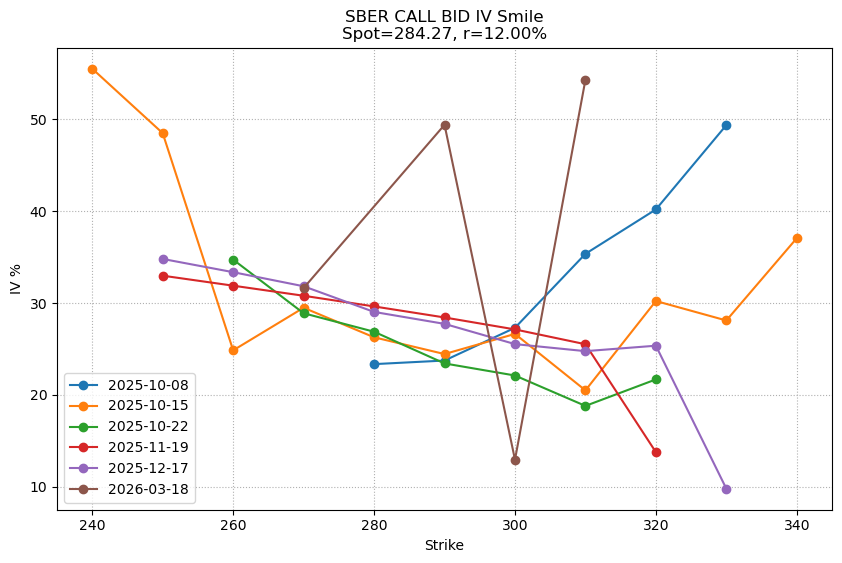

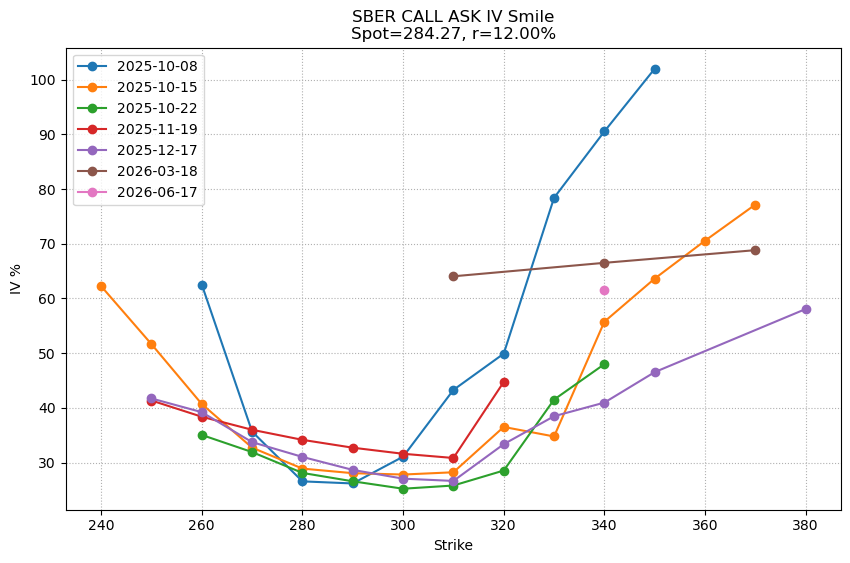

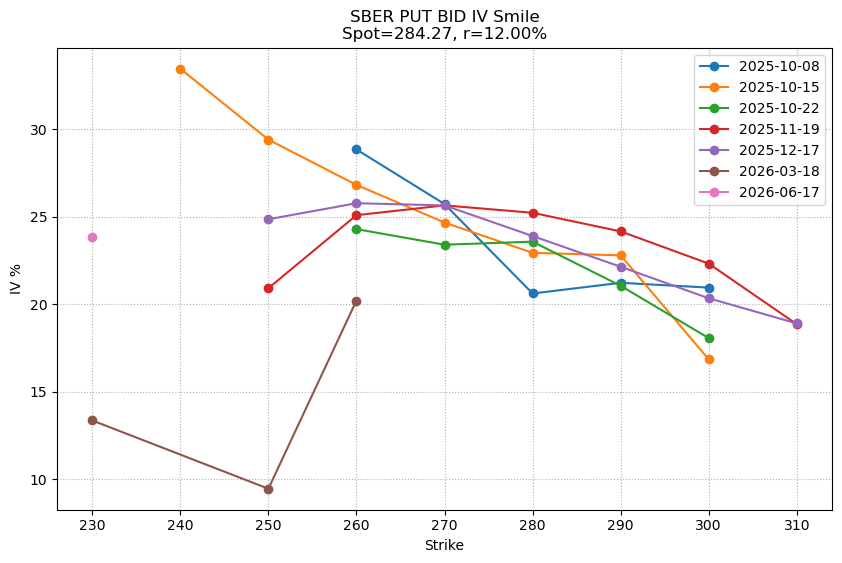

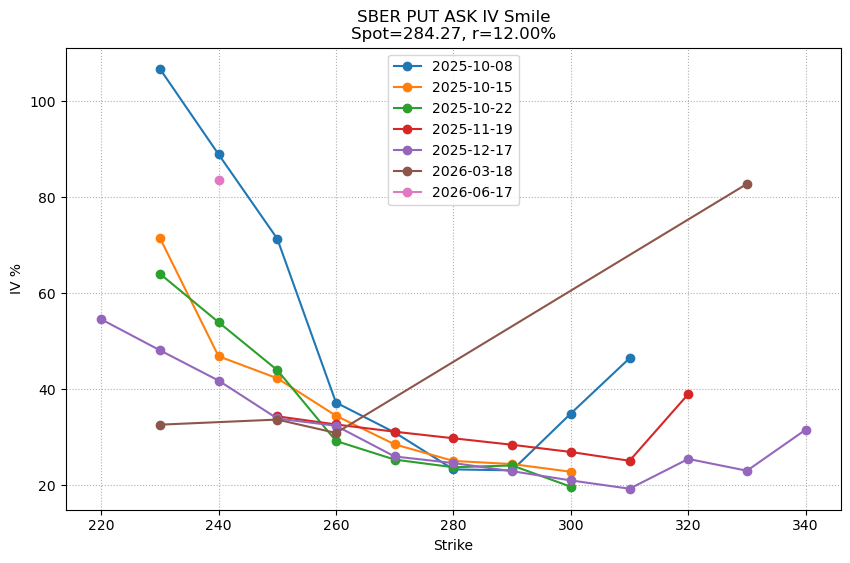

In [5]:
r = 0.12
quotes, spot = update_quotes(TOKEN, options_df, share_uid, r=r, depth=5, max_workers=15)
plot_smiles(quotes, spot, ticker, r)

Годовая волатильность: 26.96 %


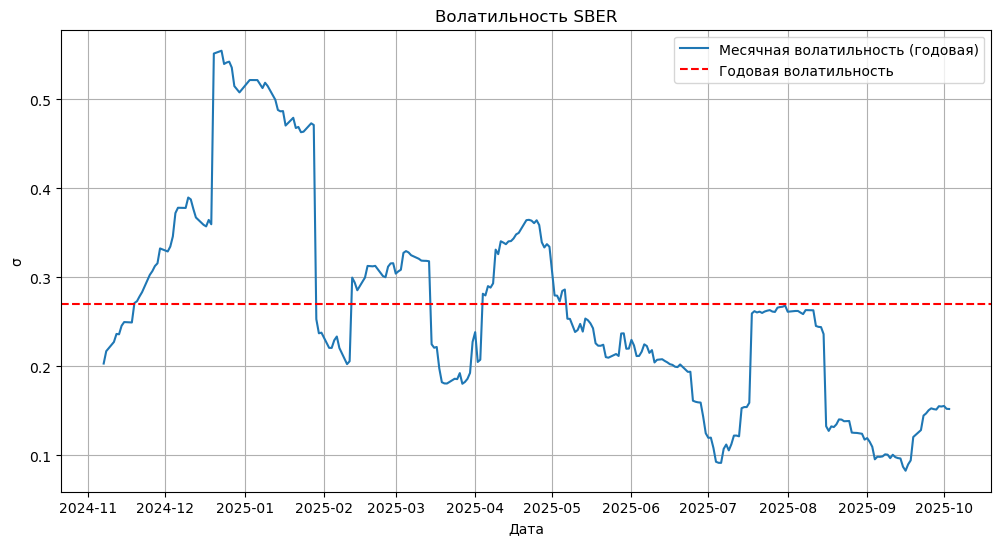

In [6]:
TICKER = "SBER"

with Client(TOKEN) as client:
    share = client.instruments.share_by(
        id_type=InstrumentIdType.INSTRUMENT_ID_TYPE_TICKER,
        id=TICKER,
        class_code="TQBR"
    ).instrument
    end_date = datetime.utcnow()
    start_date = end_date - timedelta(days=365)

    candles = client.market_data.get_candles(
        figi=share.figi,
        from_=start_date,
        to=end_date,
        interval=CandleInterval.CANDLE_INTERVAL_DAY
    ).candles

data = []
for c in candles:
    close = c.close.units + c.close.nano / 1e9
    data.append({"time": pd.to_datetime(c.time), "close": close})
df = pd.DataFrame(data).set_index("time").sort_index()

df["ret"] = np.log(df["close"] / df["close"].shift(1))

year_len = len(df)
month_len = int(len(df)/12)
sigma_year = df["ret"].std() * np.sqrt(year_len)
print("Годовая волатильность:", str(round(100*sigma_year, 2)) + " %")

df["vol_month"] = df["ret"].rolling(month_len).std() * np.sqrt(year_len)

plt.figure(figsize=(12,6))
plt.plot(df.index, df["vol_month"], label="Месячная волатильность (годовая)")
plt.axhline(sigma_year, color="red", linestyle="--", label="Годовая волатильность")
plt.title(f"Волатильность {TICKER}")
plt.xlabel("Дата")
plt.ylabel("σ")
plt.legend()
plt.grid(True)
out_dir="pics"
fname = os.path.join(out_dir, f"{TICKER}_vol.png")
plt.savefig(fname, dpi=150)
plt.show()

In [7]:
import time

import math
from scipy.stats import norm
from scipy.optimize import brentq

def bs_call_price(S, K, T, r, sigma):
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

def implied_vol_call_scipy(price, S, K, T, r):
    f = lambda sigma: bs_call_price(S, K, T, r, sigma) - price
    try:
        return brentq(f, 1e-6, 5.0)
    except ValueError:
        return None

# --- Сравнение скорости ---
S = 300
r = 0.12
T = 0.25
strikes = np.linspace(250, 350, 50)
prices = [bs_call_price(S, K, T, r, 0.3) for K in strikes]

# SciPy brentq
t0 = time.time()
ivs_scipy = [implied_vol_call_scipy(p, S, K, T, r) for p, K in zip(prices, strikes)]
t1 = time.time()

# py_vollib
t2 = time.time()
ivs_vollib = [implied_volatility(p, S, K, T, r, 'c') for p, K in zip(prices, strikes)]
t3 = time.time()

print("Время SciPy:", round(t1 - t0, 4), "сек")
print("Время py_vollib:", round(t3 - t2, 4), "сек")
print("Разница первых 5 значений:")
print("SciPy:", ivs_scipy[:5])
print("vollib:", ivs_vollib[:5])


Время SciPy: 0.0708 сек
Время py_vollib: 0.0017 сек
Разница первых 5 значений:
SciPy: [0.3000000000002593, 0.2999999999999939, 0.3000000000000024, 0.29999999999999516, 0.3000000000000109]
vollib: [0.30000000000000177, 0.3000000000000006, 0.2999999999999995, 0.2999999999999997, 0.29999999999999905]
